# Wine Price Prediction with Random Forest

## 基本情報

- 主題: Random Forest
- 作成者: 荒田禎之
- 位置づけ: Random Forest を用いた予測モデルの構築
- 使用データ: Wine Review
- 分析課題: Wine Reviews データを使い、数値・カテゴリ変数から $\log(\mathrm{price})$ を Random Forest で予測
- 到達目標: 
  - 実際のデータを用いて、Random Forest モデルを構築する
  - 何故、予測性能が十分に上がらないかを理解する  

This notebook includes code and explanations generated with OpenAI Codex.

---

## 1. 今回の方針

Wine Reviews データを使い、指定された数値・カテゴリ変数から $\log(\mathrm{price})$ を Random Forest で予測する。

ファイル操作、データ処理、可視化、機械学習に必要なライブラリを読み込む。scikit-learnからは、数値列とカテゴリ列に別々の処理を適用する `ColumnTransformer`、欠損補完、One-hot encoding、Random Forest、データ分割、評価指標を使用する。最後に、グラフの表示形式を統一している。


In [10]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

sns.set_theme(style="whitegrid")

## 1. データの読み込み

CSVをファイルを読み込む。`title` と `description` の組が同じ行を同一レビューとみなして重複を除外する。読み込み元、削除した重複件数、重複除外後の行列数を表示し、モデル作成に使うデータの規模を確認する。


In [11]:
filename = "winemag-data-130k-v2.csv"
candidate_paths = [Path("data") / filename, Path("../data") / filename]
csv_path = next((path for path in candidate_paths if path.exists()), None)

if csv_path is None:
    searched = "\n".join(f"- {path.resolve()}" for path in candidate_paths)
    raise FileNotFoundError(f"CSV が見つかりません。以下を確認してください。\n{searched}")

df = pd.read_csv(csv_path)

# 同じ商品名・レビュー本文を持つ重複レビューを除外
rows_before = len(df)
df = df.drop_duplicates(subset=["title", "description"]).copy()
duplicates_removed = rows_before - len(df)

print(f"Loaded: {csv_path.resolve()}")
print(f"Removed duplicated reviews: {duplicates_removed:,}")
print(f"Shape after deduplication: {df.shape[0]:,} rows x {df.shape[1]:,} columns")

Loaded: /content/data/winemag-data-130k-v2.csv
Removed duplicated reviews: 9,983
Shape after deduplication: 119,988 rows x 14 columns


## 2. 説明変数と目的変数の作成

価格が欠損している行と、対数を取れない非正の価格を除外する。目的変数には自然対数を使う。

数値特徴量には評価点 `points`、カテゴリ特徴量には国、銘柄名、産地、品種、ワイナリーを指定する。価格が欠損または非正の行を除き、説明変数を `X`、価格の自然対数を目的変数 `y` とする。対数変換により高価格側の長い裾を圧縮し、極端な価格が学習へ与える影響を抑える。


In [12]:
numeric_features = ["points"]
categorical_features = [
    "country",
    "designation",
    "province",
    "region_1",
    "region_2",
    "variety",
    "winery",
]
feature_columns = numeric_features + categorical_features

model_data = df.loc[df["price"].notna() & (df["price"] > 0), feature_columns + ["price"]].copy()
X = model_data[feature_columns]
y = np.log(model_data["price"])

print(f"Rows used for modeling: {len(model_data):,}")
display(X.head())
display(y.describe().rename("log_price").to_frame())

Rows used for modeling: 111,593


,points,country,designation,province,region_1,region_2,variety,winery
1,87,Portugal,Avidagos,Douro,NaN,NaN,Portuguese Red,Quinta dos Avidagos
2,87,US,NaN,Oregon,Willamette Valley,Willamette Valley,Pinot Gris,Rainstorm
3,87,US,Reserve Late Harvest,Michigan,Lake Michigan Shore,NaN,Riesling,St. Julian
4,87,US,Vintner's Reserve Wild Child Block,Oregon,Willamette Valley,Willamette Valley,Pinot Noir,Sweet Cheeks
5,87,Spain,Ars In Vitro,Northern Spain,Navarra,NaN,Tempranillo-Merlot,Tandem


,log_price
count,111593.000000
mean,3.316905
std,0.659363
min,1.386294
25%,2.833213
50%,3.218876
75%,3.737670
max,8.101678


## 3. 前処理と Random Forest

<!-- 数値変数は中央値で欠損を補完し、カテゴリ変数の欠損は専用カテゴリ `__MISSING__` に置換する。カテゴリ変数は One-hot encoding し、出現回数10未満のカテゴリをまとめることで、`designation` や `winery` による特徴量数の増大を抑える。 -->

データを80%の訓練用と20%のテスト用に固定乱数で分割する。数値列は中央値で欠損補完し、カテゴリ列は欠損を `__MISSING__` として保持した後にOne-hot encodingする。出現回数10未満のカテゴリをまとめ、未知カテゴリは無視する設定である。これらの前処理と200本の回帰木からなるRandom Forestを1つの `Pipeline` にまとめ、訓練データへfitする。`min_samples_leaf=2` は葉に最低2件を要求し、`max_features="sqrt"` は各分岐で調べる特徴量数を制限する。


In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="constant", fill_value="__MISSING__")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", min_frequency=10)),
])

preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features),
])

model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("regressor", RandomForestRegressor(
        n_estimators=200,
        min_samples_leaf=2,
        max_features="sqrt",
        random_state=42,
        n_jobs=-1,
    )),
])

model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median'))]),
                                                  ['points']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(fill_value='__MISSING__',
                                                                                 strategy='constant')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 min_frequency=10))]),
                                                  ['country', 'designation',
                                                   'province', 'region_1',
                                                   'region_2', 'variety',
                                                   'winery'])])),
                ('regressor',
                 RandomForestRegressor(max_features='sqrt', min_samples_leaf=2,
                                       n_estimators=200, n_jobs=-1,
                                       random_state=42))])

## 4. テストデータでの評価

学習に使っていないテストデータからlog価格を予測する。RMSEは大きな誤差を強く評価し、MAEは平均的な絶対誤差、$R^2$ は目的変数の分散をモデルがどの程度説明したかを表す。最後のMAEは実測値と予測値を指数変換してドル価格へ戻した上で計算する。


In [14]:
y_pred = model.predict(X_test)

metrics = pd.Series({
    "RMSE (log price)": mean_squared_error(y_test, y_pred) ** 0.5,
    "MAE (log price)": mean_absolute_error(y_test, y_pred),
    "R2 (log price)": r2_score(y_test, y_pred),
    "MAE (price, USD)": mean_absolute_error(np.exp(y_test), np.exp(y_pred)),
})
display(metrics.to_frame("value"))

,value
RMSE (log price),0.407841
MAE (log price),0.306490
R2 (log price),0.620723
"MAE (price, USD)",12.172091


### 予測値と残差を可視化するコード

左図では実際のlog価格と予測log価格を散布図で比較し、破線の45度線に近いほど予測が正確であることを示す。右図では残差を「実際値 − 予測値」として計算し、その分布を表示する。残差が0付近を中心に対称なら系統的な過大・過小予測が小さく、裾が長ければ一部に大きな予測誤差がある。

予測値に十分な Variation がなく、そのためプロットが "寝た形" になるのは、モデルの説明力が低い場合の典型例である。

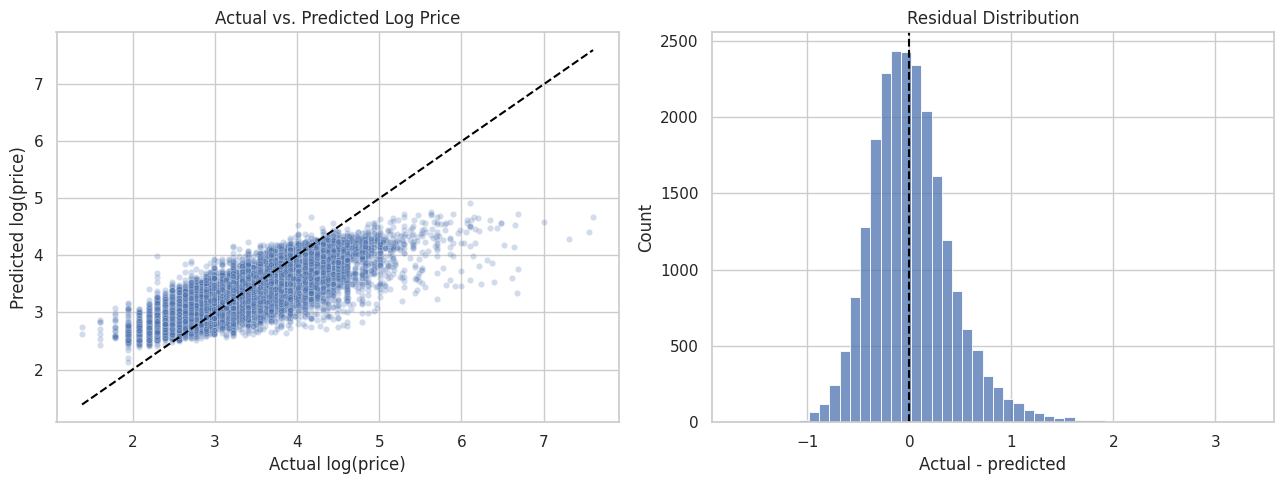

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.scatterplot(x=y_test, y=y_pred, alpha=0.25, s=20, ax=axes[0])
limits = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
axes[0].plot(limits, limits, "--", color="black")
axes[0].set(
    title="Actual vs. Predicted Log Price",
    xlabel="Actual log(price)",
    ylabel="Predicted log(price)",
)

residuals = y_test - y_pred
sns.histplot(residuals, bins=50, ax=axes[1])
axes[1].axvline(0, linestyle="--", color="black")
axes[1].set(title="Residual Distribution", xlabel="Actual - predicted")

plt.tight_layout()
plt.show()

## 5. 特徴量重要度

前処理後の数値列名とOne-hot化されたカテゴリ列名を取得し、Random Forestの不純度減少量に基づく特徴量重要度を対応付ける。重要度が高い上位20特徴量を表と横棒グラフで示し、モデルが予測時に主に利用した評価点や特定カテゴリを確認する。

,importance
num__points,0.253828
cat__variety_Pinot Noir,0.025803
cat__region_2_Napa,0.025167
cat__designation___MISSING__,0.021706
cat__designation_infrequent_sklearn,0.019793
cat__region_1_California,0.016191
cat__province_Burgundy,0.015952
cat__region_2_California Other,0.015922
cat__variety_Cabernet Sauvignon,0.014597
cat__variety_Nebbiolo,0.014534


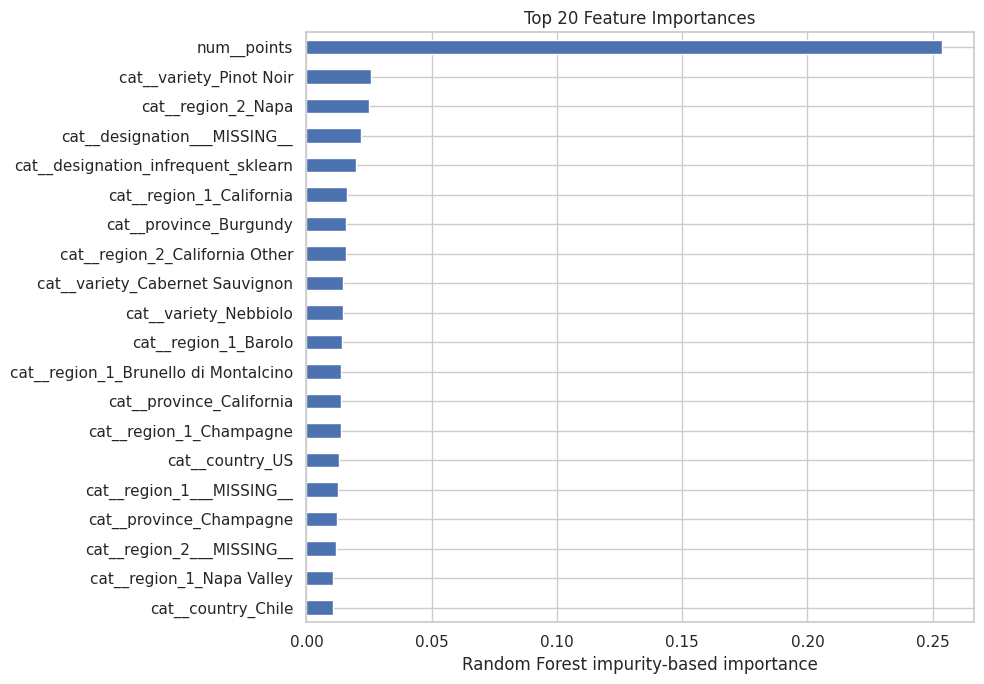

In [16]:
feature_names = model.named_steps["preprocessor"].get_feature_names_out()
feature_importance = (
    pd.Series(
        model.named_steps["regressor"].feature_importances_,
        index=feature_names,
        name="importance",
    )
    .sort_values(ascending=False)
    .head(20)
)

display(feature_importance.to_frame())

plt.figure(figsize=(10, 7))
feature_importance.sort_values().plot.barh()
plt.title("Top 20 Feature Importances")
plt.xlabel("Random Forest impurity-based importance")
plt.tight_layout()
plt.show()

`feature_importances_` は不純度減少量に基づく指標であり、カテゴリ数の多い特徴量を過大評価する場合がある。厳密な解釈が必要な場合は、テストデータを使った permutation importance も検討してよい。

## 6. 予測結果の例

テストデータの先頭10件を取り出し、対数から元のドル価格へ戻した実価格と予測価格を追加して表示する。集約指標だけでなく個別事例を確認することで、どのようなワインで予測が大きく外れるか、予測値が平均へ寄りすぎていないかを目視できる。

In [17]:
prediction_examples = X_test.head(10).copy()
prediction_examples["actual_price"] = np.exp(y_test.head(10))
prediction_examples["predicted_price"] = np.exp(model.predict(X_test.head(10)))
display(prediction_examples)

,points,country,designation,province,region_1,region_2,variety,winery,actual_price,predicted_price
55167,87,Chile,Barrel Series Reserva,Cachapoal Valley,NaN,NaN,Chardonnay,Casas del Toqui,14.0,17.954131
38222,90,Italy,NaN,Sicily & Sardinia,Sicilia,NaN,Chardonnay,Planeta,40.0,25.979377
32551,92,Italy,NaN,Veneto,Amarone della Valpolicella Classico,NaN,"Corvina, Rondinella, Molinara",Brigaldara,55.0,48.548300
92067,81,France,L'Alycastre,Provence,Côtes de Provence,NaN,Rosé,Domaine de la Courtade,10.0,17.511398
4407,88,US,Dry,New York,Finger Lakes,Finger Lakes,Riesling,McGregor,20.0,17.943086
60266,90,Germany,Brauneberger Juffer Kabinett,Mosel-Saar-Ruwer,NaN,NaN,Riesling,Willi Haag,18.0,31.137487
51298,86,US,Occam's Razor,Washington,Columbia Valley (WA),Columbia Valley,Red Blend,Rasa,16.0,24.504061
102934,91,France,Brut Millésimé,Champagne,Champagne,NaN,Champagne Blend,Chassenay d'Arce,60.0,64.862529
89464,95,US,7200 Grassini Family Vineyard,California,Happy Canyon of Santa Barbara,Central Coast,Cabernet Sauvignon,Foxen 7200,44.0,46.956562
2246,94,US,Dutton Palms Vineyard Dutton Ranch,California,Russian River Valley,Sonoma,Chardonnay,Dutton Estate,40.0,43.263603
